# Exploracao Compilada dos Sensores

Este notebook consolida os artefatos gerados pelos notebooks individuais:
- `exploracao_sentinel2_long.ipynb`
- `exploracao_landsat89_long.ipynb`
- `exploracao_modis_long.ipynb`

Ele compara estatisticas de bandas, indices e hipoteses para orientar a etapa de modelagem integrada.


## 1) Setup


In [1]:
%pip install pandas matplotlib seaborn

In [2]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / 'src').exists() and (cwd / 'notebooks').exists():
        return cwd
    if cwd.name == 'notebooks' and (cwd.parent / 'src').exists():
        return cwd.parent
    return cwd


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Carregamento dos artefatos


In [8]:
PROJECT_ROOT = resolve_project_root()
PROJECT_ROOT = PROJECT_ROOT / 'drive' / 'MyDrive' / 'SpectraAI' / 'outputs'

OUTPUT_DIR = PROJECT_ROOT

SENSORS = {
    'sentinel2': 'Sentinel2',
    'landsat89': 'Landsat 89',
    'modis': 'modis',
}

print('Lendo artefatos em:', OUTPUT_DIR)

def load_sensor_artifacts(sensor_key: str):
    overview_path = OUTPUT_DIR / f'{sensor_key}_overview.json'
    band_path = OUTPUT_DIR / f'{sensor_key}_band_summary.csv'
    index_path = OUTPUT_DIR / f'{sensor_key}_index_summary.csv'
    hypothesis_path = OUTPUT_DIR / f'{sensor_key}_hypotheses.txt'
    image_counts_path = OUTPUT_DIR / f'{sensor_key}_image_counts.csv'

    data = {
        'overview': None,
        'band_summary': pd.DataFrame(),
        'index_summary': pd.DataFrame(),
        'hypotheses': [],
        'image_counts': pd.DataFrame(),
    }

    if overview_path.exists():
        data['overview'] = json.loads(overview_path.read_text(encoding='utf-8'))
    if band_path.exists():
        data['band_summary'] = pd.read_csv(band_path)
    if index_path.exists():
        data['index_summary'] = pd.read_csv(index_path)
    if hypothesis_path.exists():
        data['hypotheses'] = [
            line.strip() for line in hypothesis_path.read_text(encoding='utf-8').splitlines() if line.strip()
        ]
    if image_counts_path.exists():
        data['image_counts'] = pd.read_csv(image_counts_path)

    return data


artifacts = {k: load_sensor_artifacts(k) for k in SENSORS}

for sensor_key, artifact in artifacts.items():
    ok = artifact['overview'] is not None and not artifact['band_summary'].empty
    status = 'OK' if ok else 'INCOMPLETO'
    print(f'- {SENSORS[sensor_key]}: {status}')


Lendo artefatos em: /content/drive/MyDrive/SpectraAI/outputs
- Sentinel2: OK
- Landsat 89: OK
- modis: OK


## 3) Resumo geral por sensor


,sensor_key,sensor_name,sensor,n_rows_total,n_rows_analysis,n_columns,n_bands,n_images
0,sentinel2,Sentinel2,Sentinel-2,93963765,93963765,13,12,1356
1,landsat89,Landsat 89,Landsat 8/9,105977560,105977560,8,7,1532
2,modis,modis,MODIS,109016100,109016100,8,7,1575


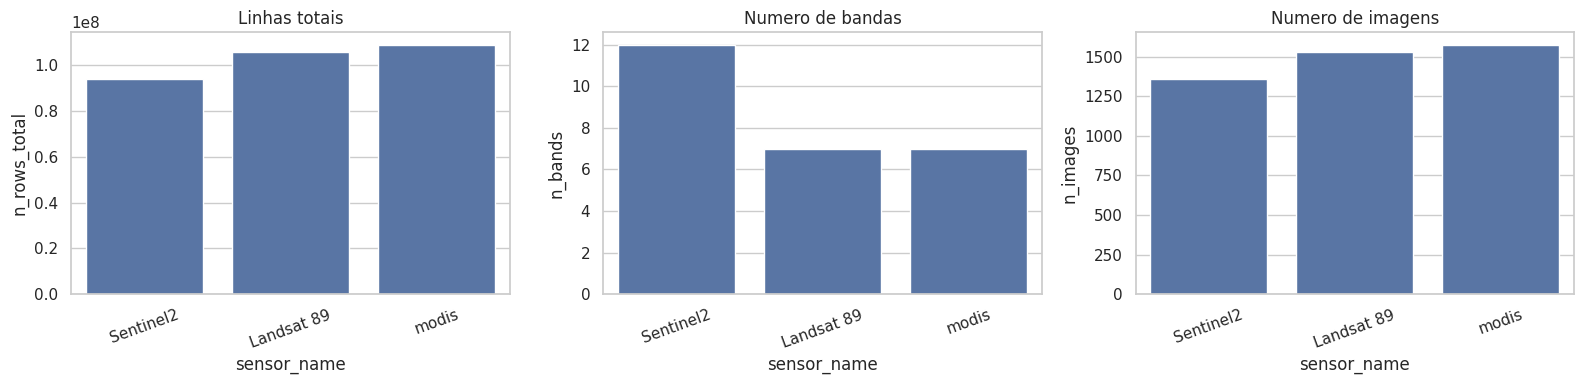

In [9]:
overview_rows = []
for sensor_key, artifact in artifacts.items():
    overview = artifact['overview']
    if overview is None:
        continue
    row = {'sensor_key': sensor_key, 'sensor_name': SENSORS[sensor_key], **overview}
    overview_rows.append(row)

overview_df = pd.DataFrame(overview_rows)
display(overview_df)

if not overview_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    sns.barplot(data=overview_df, x='sensor_name', y='n_rows_total', ax=axes[0])
    axes[0].set_title('Linhas totais')
    axes[0].tick_params(axis='x', rotation=20)

    sns.barplot(data=overview_df, x='sensor_name', y='n_bands', ax=axes[1])
    axes[1].set_title('Numero de bandas')
    axes[1].tick_params(axis='x', rotation=20)

    if 'n_images' in overview_df.columns:
        sns.barplot(data=overview_df, x='sensor_name', y='n_images', ax=axes[2])
        axes[2].set_title('Numero de imagens')
        axes[2].tick_params(axis='x', rotation=20)

    plt.tight_layout()
    plt.show()


## 4) Comparativo de estatisticas por banda


,band,count,mean,std,min,p01,p10,p50,p90,p99,max,missing_pct,zero_pct,sensor_key,sensor_name
0,B1,93963765.0,340.474304,143.075348,0.0,0.0,186.0,326.0,524.0,716.0,1990.0,0.0,2.841745,sentinel2,Sentinel2
1,B2,93963765.0,437.974884,207.373230,0.0,0.0,202.0,424.0,695.0,1000.0,6632.0,0.0,2.824359,sentinel2,Sentinel2
2,B3,93963765.0,694.415100,281.843048,0.0,0.0,394.0,670.0,1038.0,1472.0,7124.0,0.0,2.807055,sentinel2,Sentinel2
3,B4,93963765.0,876.179382,484.311462,0.0,0.0,298.0,846.0,1510.0,2154.0,7208.0,0.0,2.807206,sentinel2,Sentinel2
4,B5,93963765.0,1304.651001,487.405762,0.0,0.0,787.0,1271.0,1920.0,2515.0,5300.0,0.0,2.806985,sentinel2,Sentinel2


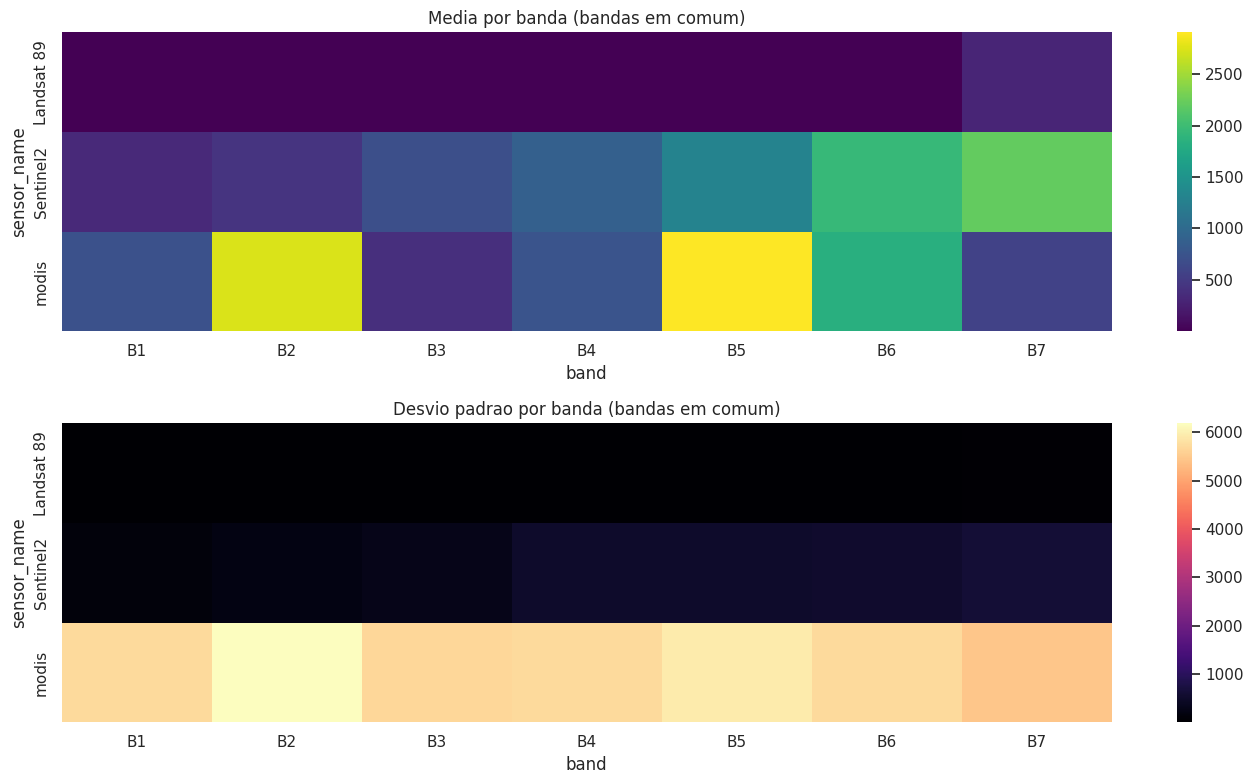

,missing_pct_medio
sensor_name,
Landsat 89,0.0
Sentinel2,0.0
modis,0.0


In [10]:
band_frames = []
for sensor_key, artifact in artifacts.items():
    df = artifact['band_summary']
    if df.empty:
        continue
    df = df.copy()
    df['sensor_key'] = sensor_key
    df['sensor_name'] = SENSORS[sensor_key]
    band_frames.append(df)

if band_frames:
    band_all = pd.concat(band_frames, ignore_index=True)
    display(band_all.head())

    common_bands = (
        band_all.groupby('band')['sensor_key'].nunique()
        .pipe(lambda s: s[s == len(band_all['sensor_key'].unique())])
        .index
        .tolist()
    )

    if common_bands:
        mean_pivot = (
            band_all[band_all['band'].isin(common_bands)]
            .pivot_table(index='sensor_name', columns='band', values='mean')
            .sort_index(axis=1)
        )

        std_pivot = (
            band_all[band_all['band'].isin(common_bands)]
            .pivot_table(index='sensor_name', columns='band', values='std')
            .sort_index(axis=1)
        )

        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        sns.heatmap(mean_pivot, cmap='viridis', ax=axes[0])
        axes[0].set_title('Media por banda (bandas em comum)')

        sns.heatmap(std_pivot, cmap='magma', ax=axes[1])
        axes[1].set_title('Desvio padrao por banda (bandas em comum)')

        plt.tight_layout()
        plt.show()
    else:
        print('Nao ha intersecao completa de bandas entre todos os sensores.')

    missing_view = band_all.groupby('sensor_name')['missing_pct'].mean().sort_values()
    display(missing_view.to_frame('missing_pct_medio'))
else:
    band_all = pd.DataFrame()
    print('Nenhum band_summary encontrado.')


## 5) Comparativo de indices espectrais


,sensor_name,index_name,mean,std,min,max
0,Sentinel2,NDVI,0.466896,0.201014,-0.642276,0.992431
1,Sentinel2,NDWI,-0.540513,0.123087,-0.939994,0.865854
2,Sentinel2,NBR,0.197866,0.204640,-0.600000,0.869876
3,Sentinel2,EVI,0.964388,0.921003,-325.000000,67.534248
4,Landsat 89,NDVI,-0.086193,0.827174,-213.400360,187.000046
5,Landsat 89,NDWI,-0.561558,0.118666,-13.820514,1.083275
6,Landsat 89,NBR,-0.998587,0.000624,-1.000012,-0.992373
7,Landsat 89,EVI,-0.028751,0.083274,-0.311862,0.583366
8,modis,NDVI,0.481508,0.304586,-55.666668,36.200001
9,modis,NDWI,-0.467639,0.253070,-3.255319,6.263158


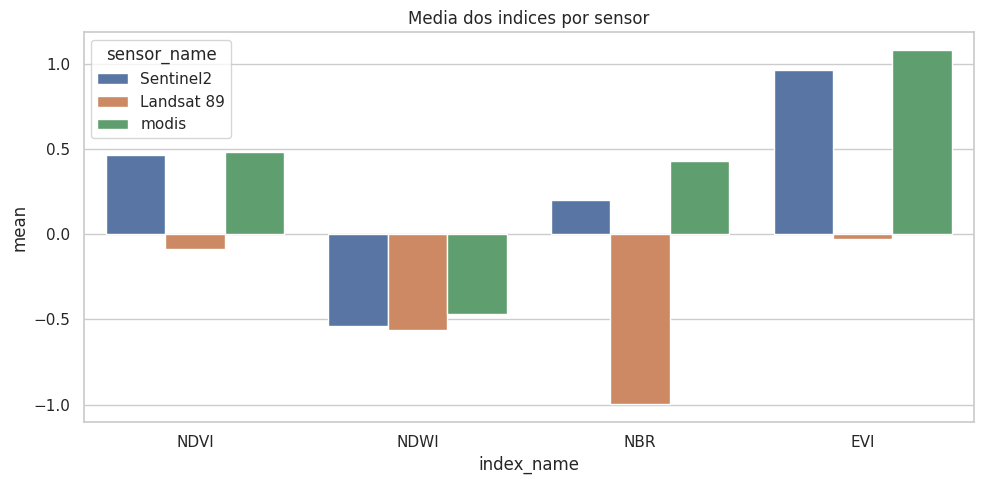

In [11]:
index_frames = []
for sensor_key, artifact in artifacts.items():
    idx_df = artifact['index_summary']
    if idx_df.empty:
        continue
    idx_df = idx_df.copy()
    idx_df['sensor_key'] = sensor_key
    idx_df['sensor_name'] = SENSORS[sensor_key]
    index_frames.append(idx_df)

if index_frames:
    index_all = pd.concat(index_frames, ignore_index=True)
    display(index_all[['sensor_name', 'index_name', 'mean', 'std', 'min', 'max']])

    plt.figure(figsize=(10, 5))
    sns.barplot(data=index_all, x='index_name', y='mean', hue='sensor_name')
    plt.title('Media dos indices por sensor')
    plt.tight_layout()
    plt.show()
else:
    index_all = pd.DataFrame()
    print('Nenhum indice foi salvo nos artefatos.')


## 6) Hipoteses consolidadas


In [12]:
hyp_rows = []
for sensor_key, artifact in artifacts.items():
    for idx, text in enumerate(artifact['hypotheses'], start=1):
        hyp_rows.append({
            'sensor_name': SENSORS[sensor_key],
            'ordem': idx,
            'hipotese': text,
        })

hyp_df = pd.DataFrame(hyp_rows)
display(hyp_df)

integrated_hypotheses = []

if not overview_df.empty and 'n_rows_total' in overview_df.columns:
    largest = overview_df.sort_values('n_rows_total', ascending=False).iloc[0]['sensor_name']
    integrated_hypotheses.append(
        f'O sensor com maior volume de pixels e {largest}; testar estrategias de balanceamento na etapa integrada.'
    )

if not band_all.empty:
    high_missing_sensor = band_all.groupby('sensor_name')['missing_pct'].mean().sort_values(ascending=False).index[0]
    integrated_hypotheses.append(
        f'{high_missing_sensor} apresentou maior taxa media de faltantes nas bandas; avaliar imputacao/mascara especifica por sensor.'
    )

if not index_all.empty and 'NDVI' in index_all['index_name'].values:
    ndvi_spread = (
        index_all[index_all['index_name'] == 'NDVI']
        .set_index('sensor_name')['mean']
        .sort_values()
    )
    if len(ndvi_spread) >= 2:
        integrated_hypotheses.append(
            'As medias de NDVI variam entre sensores; testar normalizacao por sensor antes de treinar modelos unificados.'
        )

if not integrated_hypotheses:
    integrated_hypotheses.append('Rodar todos os notebooks individuais para gerar evidencias comparativas mais fortes.')

print('Hipoteses integradas')
for i, h in enumerate(integrated_hypotheses, start=1):
    print(f'{i}. {h}')


,sensor_name,ordem,hipotese
0,Sentinel2,1,"Bandas com maior variabilidade (B11, B12, B9) ..."
1,Sentinel2,2,Existe redundancia espectral relevante em B7~B...
2,Sentinel2,3,Ha variacao entre imagens na media espectral. ...
3,Sentinel2,4,NDVI medio=0.467 (std=0.201). Testar mascarame...
4,Landsat 89,1,"Bandas com maior variabilidade (B7, B5, B4) po..."
5,Landsat 89,2,Existe redundancia espectral relevante em B5~B...
6,Landsat 89,3,Ha variacao entre imagens na media espectral. ...
7,Landsat 89,4,NDVI medio=-0.086 (std=0.827). Testar mascaram...
8,modis,1,"Bandas com maior variabilidade (B2, B5, B1) po..."
9,modis,2,Existe redundancia espectral relevante em B1~B...


Hipoteses integradas
1. O sensor com maior volume de pixels e modis; testar estrategias de balanceamento na etapa integrada.
2. Landsat 89 apresentou maior taxa media de faltantes nas bandas; avaliar imputacao/mascara especifica por sensor.
3. As medias de NDVI variam entre sensores; testar normalizacao por sensor antes de treinar modelos unificados.


## 7) Exportacao do compilado


In [13]:
compile_overview_path = OUTPUT_DIR / 'compilado_overview.csv'
compile_hyp_path = OUTPUT_DIR / 'compilado_hipoteses.txt'

if not overview_df.empty:
    overview_df.to_csv(compile_overview_path, index=False)

compile_hyp_path.write_text('\n'.join(integrated_hypotheses), encoding='utf-8')

print('Arquivos salvos:')
if compile_overview_path.exists():
    print('-', compile_overview_path)
print('-', compile_hyp_path)


Arquivos salvos:
- /content/drive/MyDrive/SpectraAI/outputs/compilado_overview.csv
- /content/drive/MyDrive/SpectraAI/outputs/compilado_hipoteses.txt
